# D.C. Property Crime
##### Analyzing how different property crimes are spacially clustered and if they're associated with certain variables
##### GGS 366: Spatial Computing
##### Shannon Malach

#### Importing Files From Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import geopandas as gpd

# identifying the file path and loading it
file_path = r"/content/drive/MyDrive/GGS 366/sm_crime_per_tract.gpkg"
gdf = gpd.read_file(file_path)

# displaying the data
print(gdf.head())
print(gdf.columns)
print(gdf.crs)

         GEOID  burglary_count  motor_vehicle_theft_count  robbery_count  \
0  11001005302             3.0                        5.0            4.0   
1  11001004402            20.0                       57.0           65.0   
2  11001010602            15.0                      121.0           22.0   
3  11001000804             4.0                        2.0            0.0   
4  11001003902             1.0                        5.0            2.0   

   theft_from_auto_count  crime_total  \
0                    7.0         19.0   
1                  170.0        312.0   
2                   67.0        225.0   
3                   27.0         33.0   
4                   12.0         20.0   

                                            geometry  
0  POLYGON ((-8576239.474 4709007.488, -8576204.2...  
1  POLYGON ((-8575157.671 4709687.774, -8575157.5...  
2  POLYGON ((-8572094.27 4707717.287, -8572062.65...  
3  POLYGON ((-8583308.039 4709824.981, -8583306.8...  
4  POLYGON ((-8577145

#### Global Spatial Autocorrelation

In [ ]:
# importing Queen to define and weight neighbors
from libpysal.weights import Queen

# creating contiguity weights
w = Queen.from_dataframe(gdf)

# row-standardize
w.transform = "r"

/tmp/ipykernel_7872/357860328.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


In [ ]:
# importing Moran's I function
from esda.moran import Moran

# defining the variable
y = gdf["burglary_count"]

# calculating Global Moran's I based on the contiguity weights and variable
moran = Moran(y, w)

# printing Global Moran's I and p-value for burgulary
print("Moran's I:", moran.I)
print("p-value:", moran.p_sim)

Moran's I: 0.17071101021137042
p-value: 0.001


In [ ]:
# defining the variable
y = gdf["motor_vehicle_theft_count"]

# calculating Moran's based on the contiguity weights and variable
moran = Moran(y, w)

# printing Moran's I and p-value for motor vehicle theft
print("Moran's I:", moran.I)
print("p-value:", moran.p_sim)

Moran's I: 0.4819932008030473
p-value: 0.001


In [ ]:
# defining the variable
y = gdf["robbery_count"]

# calculating Moran's based on the contiguity weights and variable
moran = Moran(y, w)

# printing Moran's I and p-value for robbery
print("Moran's I:", moran.I)
print("p-value:", moran.p_sim)

Moran's I: 0.370151553604442
p-value: 0.001


In [ ]:
# defining the variable
y = gdf["theft_from_auto_count"]

# calculating Global Moran's I based on the contiguity weights and variable
moran = Moran(y, w)

# printing Global Moran's I and p-value for theft from motor vehicles
print("Moran's I:", moran.I)
print("p-value:", moran.p_sim)

Moran's I: 0.20797199871725383
p-value: 0.001


#### Local Spatial Autocorrelation

In [ ]:
from esda.moran import Moran_Local

# defining the crime type to run Local Moran's I on
y = gdf["burglary_count"]

# calculating Local Moran's I
lisa = Moran_Local(y, w)

# storing results from Local Moran's I
gdf["local_I"] = lisa.Is
gdf["p_value"] = lisa.p_sim

# clustering categories
gdf["cluster"] = lisa.q

# creating cluster labels and assessing significance
gdf["cluster_label"] = "Not Significant"
gdf.loc[(gdf["cluster"] == 1) & (gdf["p_value"] < 0.05), "cluster_label"] = "High-High"
gdf.loc[(gdf["cluster"] == 2) & (gdf["p_value"] < 0.05), "cluster_label"] = "Low-Low"
gdf.loc[(gdf["cluster"] == 3) & (gdf["p_value"] < 0.05), "cluster_label"] = "High-Low"
gdf.loc[(gdf["cluster"] == 4) & (gdf["p_value"] < 0.05), "cluster_label"] = "Low-High"

# displaying tracts with positive spatial autocorrelation with their Local Moran's I and p-values
gdf[gdf["cluster_label"] == "High-High"] \
    .sort_values(by="local_I", ascending=False) \
    [["GEOID", "local_I", "p_value"]]

,GEOID,local_I,p_value
176,11001009000,2.936483,0.021
168,11001008803,2.844666,0.007
175,11001011100,2.590650,0.007
71,11001007903,2.112347,0.018
177,11001009102,1.834312,0.022
105,11001004801,1.284555,0.028
170,11001008903,1.267534,0.032
202,11001002900,1.245873,0.009
171,11001008904,1.235370,0.001
185,11001009301,0.390967,0.013


In [ ]:
# displaying tracts with negative spatial autocorrelation with their Local Moran's I and p-values
gdf[gdf["cluster_label"] == "Low-Low"] \
    .sort_values(by="local_I") \
    [["GEOID", "local_I", "p_value"]]

,GEOID,local_I,p_value
73,11001009400,-1.038469,0.009
13,11001002703,-0.856313,0.014
99,11001009604,-0.777789,0.026
26,11001002503,-0.649869,0.014
140,11001009601,-0.525083,0.013
89,11001002801,-0.449070,0.025
169,11001008804,-0.404368,0.001
186,11001009302,-0.392060,0.033
44,11001010601,-0.332674,0.022
172,11001008802,-0.233464,0.005


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

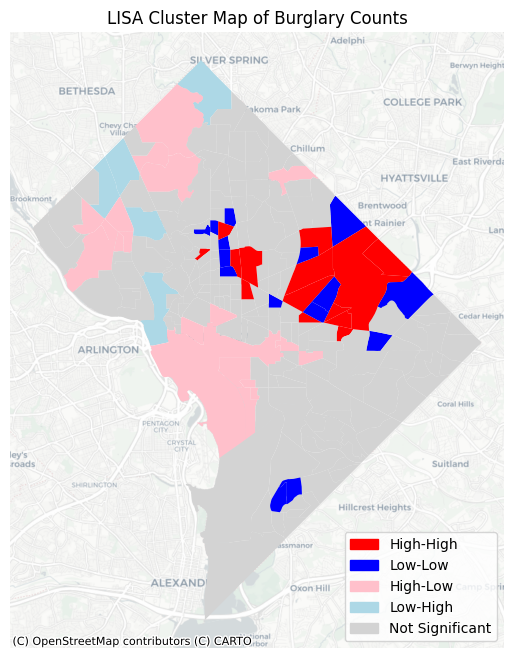

In [ ]:
# installing contextily for basemaps
!pip install contextily

# importing NumPy
import numpy as np

# Calculating LISA for burglary_count using the tracts GeoDataFrame
from esda.moran import Moran_Local

# defining the crime type to run Local Moran's I on
y = tracts["burglary_count"]

# calculating Local Moran's I
lisa = Moran_Local(y, w)

# applying a significance filter
sig = 0.05
significant = lisa.p_sim < sig

# creating cluster map variable on 'tracts'
tracts["lisa_cluster"] = 0
tracts.loc[significant, "lisa_cluster"] = lisa.q[significant]

# creating cluster labels and assessing significance for tracts
tracts["cluster_label"] = "Not Significant"
tracts.loc[(lisa.q == 1) & (lisa.p_sim < sig), "cluster_label"] = "High-High"
tracts.loc[(lisa.q == 2) & (lisa.p_sim < sig), "cluster_label"] = "Low-Low"
tracts.loc[(lisa.q == 3) & (lisa.p_sim < sig), "cluster_label"] = "High-Low"
tracts.loc[(lisa.q == 4) & (lisa.p_sim < sig), "cluster_label"] = "Low-High"

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx

# Defining LISA colors
color_dict = {
    "High-High": "red",
    "Low-Low": "blue",
    "High-Low": "pink",
    "Low-High": "lightblue",
    "Not Significant": "lightgrey"
}

tracts["color"] = tracts["cluster_label"].map(color_dict)

# plotting the Local Spatial Autocorrelation
fig, ax = plt.subplots(figsize=(8, 8))
tracts.plot(color=tracts["color"], ax=ax)
# adding CartoDB Positron basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    zoom=12
)

# setting the legend
legend_patches = [
    mpatches.Patch(color="red", label="High-High"),
    mpatches.Patch(color="blue", label="Low-Low"),
    mpatches.Patch(color="pink", label="High-Low"),
    mpatches.Patch(color="lightblue", label="Low-High"),
    mpatches.Patch(color="lightgrey", label="Not Significant")
]
ax.legend(handles=legend_patches, loc="lower right")

# setting the title
ax.set_title("LISA Cluster Map of Burglary Counts")
ax.set_axis_off()

# saving and exporting the map
plt.savefig("map.png", dpi=300, bbox_inches='tight')
from google.colab import files
files.download("map.png")

# displaying map
plt.show()

In [ ]:
# defining the crime type to run Local Moran's I on
y = gdf["motor_vehicle_theft_count"]

# calculating Local Moran's I
lisa = Moran_Local(y, w)

# storing results from Local Moran's I
gdf["local_I"] = lisa.Is
gdf["p_value"] = lisa.p_sim

# clustering categories
gdf["cluster"] = lisa.q

# creating cluster labels and assessing significance
gdf["cluster_label"] = "Not Significant"
gdf.loc[(gdf["cluster"] == 1) & (gdf["p_value"] < 0.05), "cluster_label"] = "High-High"
gdf.loc[(gdf["cluster"] == 2) & (gdf["p_value"] < 0.05), "cluster_label"] = "Low-Low"
gdf.loc[(gdf["cluster"] == 3) & (gdf["p_value"] < 0.05), "cluster_label"] = "High-Low"
gdf.loc[(gdf["cluster"] == 4) & (gdf["p_value"] < 0.05), "cluster_label"] = "Low-High"

# displaying tracts with positive spatial autocorrelation with their Local Moran's I and p-values
gdf[gdf["cluster_label"] == "High-High"] \
    .sort_values(by="local_I", ascending=False) \
    [["GEOID", "local_I", "p_value"]]

,GEOID,local_I,p_value
168,11001008803,12.357882,0.001
2,11001010602,7.527633,0.001
162,11001008702,5.702244,0.001
44,11001010601,4.786318,0.001
176,11001009000,4.465824,0.032
175,11001011100,3.545594,0.002
177,11001009102,2.916323,0.001
43,11001010603,2.274358,0.018
172,11001008802,2.221744,0.001
73,11001009400,1.870209,0.037


In [ ]:
# displaying tracts with negative spatial autocorrelation with their Local Moran's I and p-values
gdf[gdf["cluster_label"] == "Low-Low"] \
    .sort_values(by="local_I") \
    [["GEOID", "local_I", "p_value"]]

,GEOID,local_I,p_value
186,11001009302,-0.352948,0.041
41,11001004704,-0.327193,0.021
169,11001008804,-0.203460,0.001
138,11001009902,-0.191308,0.035
115,11001008301,-0.039375,0.020
58,11001009906,-0.027833,0.037


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

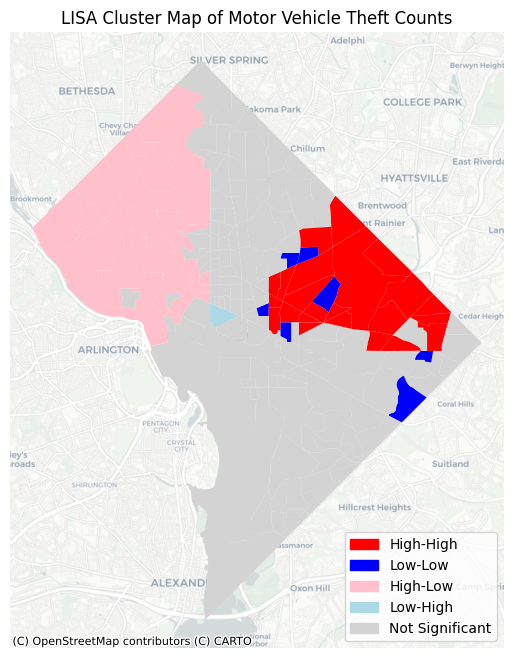

In [ ]:
# applying a significance filter
sig = 0.05

# Define the variable for LISA calculation using 'tracts'
y = tracts["motor_vehicle_theft_count"]

# calculating local autocorrelation
from esda.moran import Moran_Local
lisa = Moran_Local(y, w)

significant = lisa.p_sim < sig

# creating cluster map variable on 'tracts'
tracts["lisa_cluster"] = 0
tracts.loc[significant, "lisa_cluster"] = lisa.q[significant]

# creating cluster labels and assessing significance for tracts
tracts["cluster_label"] = "Not Significant"
tracts.loc[(lisa.q == 1) & (lisa.p_sim < sig), "cluster_label"] = "High-High"
tracts.loc[(lisa.q == 2) & (lisa.p_sim < sig), "cluster_label"] = "Low-Low"
tracts.loc[(lisa.q == 3) & (lisa.p_sim < sig), "cluster_label"] = "High-Low"
tracts.loc[(lisa.q == 4) & (lisa.p_sim < sig), "cluster_label"] = "Low-High"

# defining LISA colors
color_dict = {
    "High-High": "red",
    "Low-Low": "blue",
    "High-Low": "pink",
    "Low-High": "lightblue",
    "Not Significant": "lightgrey"
}

tracts["color"] = tracts["cluster_label"].map(color_dict)

# plotting the Local Spatial Autocorrelation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx

fig, ax = plt.subplots(figsize=(8, 8))
tracts.plot(color=tracts["color"], ax=ax)

# adding CartoDB Positron basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    zoom=12
)

# setting the legend
legend_patches = [
    mpatches.Patch(color="red", label="High-High"),
    mpatches.Patch(color="blue", label="Low-Low"),
    mpatches.Patch(color="pink", label="High-Low"),
    mpatches.Patch(color="lightblue", label="Low-High"),
    mpatches.Patch(color="lightgrey", label="Not Significant")
]
ax.legend(handles=legend_patches, loc="lower right")

# setting the title
ax.set_title("LISA Cluster Map of Motor Vehicle Theft Counts")
ax.set_axis_off()

# saving and exporting the map
plt.savefig("map.png", dpi=300, bbox_inches='tight')
from google.colab import files
files.download("map.png")

# displaying map
plt.show()

In [ ]:
# defining the crime type to run Local Moran's I on
y = gdf["robbery_count"]

# calculating Local Moran's I
lisa = Moran_Local(y, w)

# storing results from Local Moran's I
gdf["local_I"] = lisa.Is
gdf["p_value"] = lisa.p_sim

# clustering categories
gdf["cluster"] = lisa.q

# creating cluster labels and assessing significance
gdf["cluster_label"] = "Not Significant"
gdf.loc[(gdf["cluster"] == 1) & (gdf["p_value"] < 0.05), "cluster_label"] = "High-High"
gdf.loc[(gdf["cluster"] == 2) & (gdf["p_value"] < 0.05), "cluster_label"] = "Low-Low"
gdf.loc[(gdf["cluster"] == 3) & (gdf["p_value"] < 0.05), "cluster_label"] = "High-Low"
gdf.loc[(gdf["cluster"] == 4) & (gdf["p_value"] < 0.05), "cluster_label"] = "Low-High"

# displaying tracts with positive spatial autocorrelation with their Local Moran's I and p-values
gdf[gdf["cluster_label"] == "High-High"] \
    .sort_values(by="local_I", ascending=False) \
    [["GEOID", "local_I", "p_value"]]

,GEOID,local_I,p_value
14,11001004401,6.265124,0.001
1,11001004402,5.188749,0.008
201,11001003500,4.512748,0.001
203,11001003100,2.440724,0.007
93,11001003600,2.350105,0.002
168,11001008803,2.218857,0.009
202,11001002900,2.146282,0.007
105,11001004801,1.893460,0.001
177,11001009102,1.693225,0.025
120,11001003000,1.395193,0.001


In [ ]:
# displaying tracts with negative spatial autocorrelation with their Local Moran's I and p-values
gdf[gdf["cluster_label"] == "Low-Low"] \
    .sort_values(by="local_I") \
    [["GEOID", "local_I", "p_value"]]

,GEOID,local_I,p_value
169,11001008804,-0.755581,0.007
13,11001002703,-0.687289,0.023
171,11001008904,-0.381759,0.032
129,11001009602,-0.367070,0.030
140,11001009601,-0.294201,0.011
99,11001009604,-0.273459,0.037
186,11001009302,-0.216237,0.035
73,11001009400,-0.155527,0.021
138,11001009902,-0.090622,0.048
58,11001009906,-0.014358,0.032


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

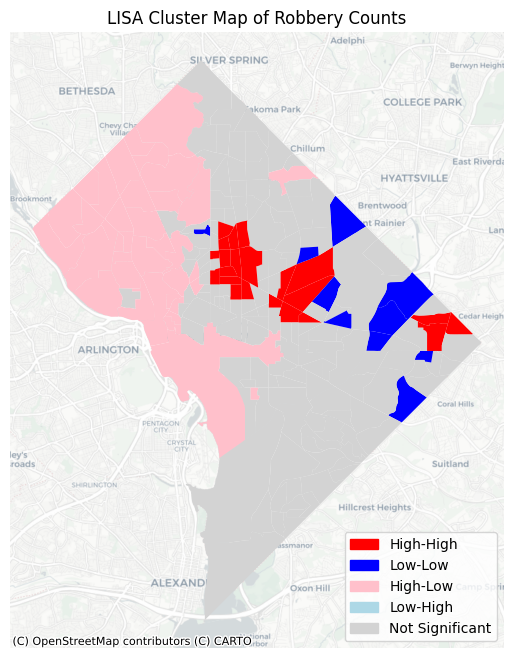

In [ ]:
y = tracts["robbery_count"]

from esda.moran import Moran_Local
# Recalculate LISA for robbery_count using the tracts GeoDataFrame
lisa = Moran_Local(y, w)

# applying a significance filter
sig = 0.05
significant = lisa.p_sim < sig

# creating cluster map variable on 'tracts'
tracts["lisa_cluster"] = 0
tracts.loc[significant, "lisa_cluster"] = lisa.q[significant]

# storing results for cluster labels in tracts
tracts["local_I"] = lisa.Is
tracts["p_value"] = lisa.p_sim
tracts["cluster"] = lisa.q
tracts["cluster_label"] = "Not Significant"
tracts.loc[(tracts["cluster"] == 1) & (tracts["p_value"] < 0.05), "cluster_label"] = "High-High"
tracts.loc[(tracts["cluster"] == 2) & (tracts["p_value"] < 0.05), "cluster_label"] = "Low-Low"
tracts.loc[(tracts["cluster"] == 3) & (tracts["p_value"] < 0.05), "cluster_label"] = "High-Low"
tracts.loc[(tracts["cluster"] == 4) & (tracts["p_value"] < 0.05), "cluster_label"] = "Low-High"

# defining LISA colors
color_dict = {
    "High-High": "red",
    "Low-Low": "blue",
    "High-Low": "pink",
    "Low-High": "lightblue",
    "Not Significant": "lightgrey"
}

tracts["color"] = tracts["cluster_label"].map(color_dict)

# plotting the Local Spatial Autocorrelation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx

fig, ax = plt.subplots(figsize=(8, 8))
tracts.plot(color=tracts["color"], ax=ax)

# adding CartoDB Positron basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    zoom=12
)

# setting the legend
legend_patches = [
    mpatches.Patch(color="red", label="High-High"),
    mpatches.Patch(color="blue", label="Low-Low"),
    mpatches.Patch(color="pink", label="High-Low"),
    mpatches.Patch(color="lightblue", label="Low-High"),
    mpatches.Patch(color="lightgrey", label="Not Significant")
]
ax.legend(handles=legend_patches, loc="lower right")

# setting the title
ax.set_title("LISA Cluster Map of Robbery Counts")
ax.set_axis_off()

# saving and exporting the map
plt.savefig("map.png", dpi=300, bbox_inches='tight')
from google.colab import files
files.download("map.png")

# displaying map
plt.show()

In [ ]:
# defining the crime type to run Local Moran's I on
y = gdf["theft_from_auto_count"]

# calculating Local Moran's I
lisa = Moran_Local(y, w)

# storing results from Local Moran's I
gdf["local_I"] = lisa.Is
gdf["p_value"] = lisa.p_sim

# clustering categories
gdf["cluster"] = lisa.q

# creating cluster labels and assessing significance
gdf["cluster_label"] = "Not Significant"
gdf.loc[(gdf["cluster"] == 1) & (gdf["p_value"] < 0.05), "cluster_label"] = "High-High"
gdf.loc[(gdf["cluster"] == 2) & (gdf["p_value"] < 0.05), "cluster_label"] = "Low-Low"
gdf.loc[(gdf["cluster"] == 3) & (gdf["p_value"] < 0.05), "cluster_label"] = "High-Low"
gdf.loc[(gdf["cluster"] == 4) & (gdf["p_value"] < 0.05), "cluster_label"] = "Low-High"

# displaying tracts with positive spatial autocorrelation with their Local Moran's I and p-values
gdf[gdf["cluster_label"] == "High-High"] \
    .sort_values(by="local_I", ascending=False) \
    [["GEOID", "local_I", "p_value"]]

,GEOID,local_I,p_value
168,11001008803,10.208632,0.001
175,11001011100,3.926274,0.028
1,11001004402,3.662204,0.037
14,11001004401,3.479581,0.039
201,11001003500,2.453839,0.012
162,11001008702,2.243232,0.013
177,11001009102,2.179591,0.001
176,11001009000,1.475980,0.004
2,11001010602,1.138024,0.010
105,11001004801,0.618598,0.015


In [ ]:
# displaying tracts with negative spatial autocorrelation with their Local Moran's I and p-values
gdf[gdf["cluster_label"] == "Low-Low"] \
    .sort_values(by="local_I") \
    [["GEOID", "local_I", "p_value"]]

,GEOID,local_I,p_value
169,11001008804,-1.051803,0.001
99,11001009604,-0.645636,0.025
71,11001007903,-0.625517,0.039
172,11001008802,-0.193747,0.006
159,11001008410,-0.180080,0.005
129,11001009602,-0.114478,0.028
171,11001008904,-0.013344,0.019


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

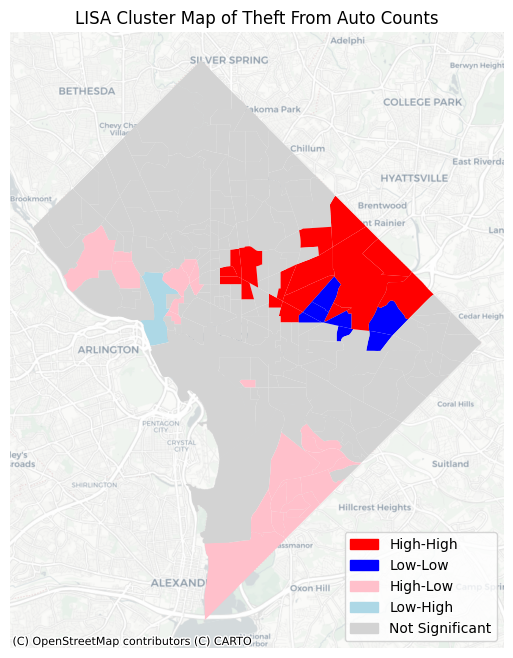

In [ ]:
# applying a significance filter
sig = 0.05
significant = lisa.p_sim < sig

# creating cluster map variable
gdf["lisa_cluster"] = 0
gdf.loc[significant, "lisa_cluster"] = lisa.q[significant]

# Defining LISA colors
color_dict = {
    "High-High": "red",
    "Low-Low": "blue",
    "High-Low": "pink",
    "Low-High": "lightblue",
    "Not Significant": "lightgrey"
}

gdf["color"] = gdf["cluster_label"].map(color_dict)

# plotting the Local Spatial Autocorrelation
fig, ax = plt.subplots(figsize=(8, 8))
gdf.plot(color=gdf["color"], ax=ax)

# adding CartoDB Positron basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    zoom=12
)

# setting the legend
legend_patches = [
    mpatches.Patch(color="red", label="High-High"),
    mpatches.Patch(color="blue", label="Low-Low"),
    mpatches.Patch(color="pink", label="High-Low"),
    mpatches.Patch(color="lightblue", label="Low-High"),
    mpatches.Patch(color="lightgrey", label="Not Significant")
]
ax.legend(handles=legend_patches, loc="lower right")

# setting the title
ax.set_title("LISA Cluster Map of Theft From Auto Counts")
ax.set_axis_off()

# saving and exporting the map
plt.savefig("map.png", dpi=300, bbox_inches='tight')
from google.colab import files
files.download("map.png")

# displaying map
plt.show()

#### Linear Regression

In [ ]:
# identifying the file path for liquor licenses file and loading it
file_path = r"/content/drive/MyDrive/GGS 366/sm_liquor_licenses_per_tract.gpkg"
gdf = gpd.read_file(file_path)

# displaying the data
print(gdf.head())
print(gdf.columns)
print(gdf.crs)

         GEOID  25 Percent  Arena  Bed and Breakfast  Beer and Wine  Caterer  \
0  11001000101         0.0    0.0                1.0            0.0      0.0   
1  11001000102         0.0    0.0                0.0            0.0      2.0   
2  11001000201         0.0    0.0                0.0            0.0      1.0   
3  11001000202         0.0    0.0                0.0            0.0      2.0   
4  11001000300         0.0    0.0                0.0            0.0      1.0   

   Club  Hotel  Internet  Manufacturer  ...  Retail - Full Service Grocery  \
0   0.0    0.0       0.0           0.0  ...                            2.0   
1   0.0    5.0       0.0           0.0  ...                            0.0   
2   0.0    0.0       0.0           0.0  ...                            0.0   
3   1.0    1.0       0.0           0.0  ...                            0.0   
4   0.0    0.0       0.0           0.0  ...                            0.0   

   Retail - Grocery  Retail - Liquor Store  Retail

In [ ]:
# identifying the file path for homeless shelters file and loading it
file_path = r"/content/drive/MyDrive/GGS 366/sm_homeless_shelters_per_tract.gpkg"
gdf = gpd.read_file(file_path)

# displaying the data
print(gdf.head())
print(gdf.columns)
print(gdf.crs)

         GEOID  homeless_shelter_count  \
0  11001001804                       1   
1  11001002501                       1   
2  11001002503                       1   
3  11001003000                       1   
4  11001003400                       1   

                                            geometry  
0  POLYGON ((-8575321.2 4716257.633, -8575321.311...  
1  POLYGON ((-8575655.604 4713500.794, -8575656.3...  
2  POLYGON ((-8574908.093 4712627.906, -8574907.6...  
3  POLYGON ((-8575236.931 4711672.953, -8575236.9...  
4  POLYGON ((-8574157.132 4711252.676, -8574149.3...  
Index(['GEOID', 'homeless_shelter_count', 'geometry'], dtype='object')
EPSG:3857


In [ ]:
# identifying the file path for metro stations file and loading it
file_path = r"/content/drive/MyDrive/GGS 366/sm_metro_stations_per_tract.gpkg"
gdf = gpd.read_file(file_path)

# displaying the data
print(gdf.head())
print(gdf.columns)
print(gdf.crs)

         GEOID  metro_station_count  \
0  11001000501                    1   
1  11001001100                    2   
2  11001001303                    1   
3  11001001304                    1   
4  11001001702                    1   

                                            geometry  
0  POLYGON ((-8578167.417 4709975.353, -8578161.0...  
1  POLYGON ((-8581144.322 4716054.771, -8581095.2...  
2  POLYGON ((-8578912.033 4714210.724, -8578874.9...  
3  POLYGON ((-8578454.287 4713219.126, -8578439.4...  
4  POLYGON ((-8574418.844 4717381.97, -8574415.05...  
Index(['GEOID', 'metro_station_count', 'geometry'], dtype='object')
EPSG:3857


In [ ]:
# identifying the file path for bus stops file and loading it
file_path = r"/content/drive/MyDrive/GGS 366/sm_bus_stops_per_tract.gpkg"
gdf = gpd.read_file(file_path)

# displaying the data
print(gdf.head())
print(gdf.columns)
print(gdf.crs)

         GEOID  bus_stops_count  \
0  11001000101                2   
1  11001000102               17   
2  11001000201                5   
3  11001000202               17   
4  11001000300               21   

                                            geometry  
0  POLYGON ((-8577961.587 4708865.856, -8577948.4...  
1  POLYGON ((-8579311.781 4707440.786, -8579249.9...  
2  POLYGON ((-8580424.642 4709171.296, -8580396.8...  
3  POLYGON ((-8580496.22 4708083.344, -8580494.55...  
4  POLYGON ((-8580798.564 4710389.997, -8580791.8...  
Index(['GEOID', 'bus_stops_count', 'geometry'], dtype='object')
EPSG:3857


/tmp/ipykernel_7872/909284504.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tracts[['total_liquor_licenses', 'homeless_shelter_count', 'metro_station_count', 'bus_stops_count', 'avg_house_size']].fillna(0)


array([[<Axes: title={'center': 'total_liquor_licenses'}>,
        <Axes: title={'center': 'homeless_shelter_count'}>],
       [<Axes: title={'center': 'metro_station_count'}>,
        <Axes: title={'center': 'bus_stops_count'}>]], dtype=object)

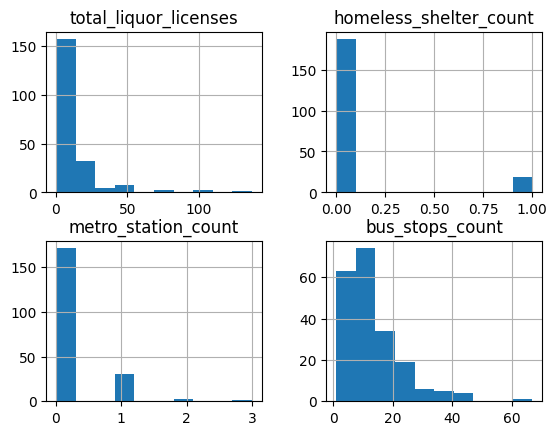

In [ ]:
import geopandas as gpd

# initializing tracts with the base crime data
tracts_file_path = r"/content/drive/MyDrive/GGS 366/sm_crime_per_tract.gpkg"
tracts = gpd.read_file(tracts_file_path)

# loading and merging liquor licenses data
liquor_licenses_gdf = gpd.read_file(r"/content/drive/MyDrive/GGS 366/sm_liquor_licenses_per_tract.gpkg")
tracts = tracts.merge(liquor_licenses_gdf[['GEOID', 'total_liquor_licenses']], on='GEOID', how='left')

# loading and merging homeless shelters data
homeless_shelters_gdf = gpd.read_file(r"/content/drive/MyDrive/GGS 366/sm_homeless_shelters_per_tract.gpkg")
tracts = tracts.merge(homeless_shelters_gdf[['GEOID', 'homeless_shelter_count']], on='GEOID', how='left')

# loading and merging metro stations data
metro_stations_gdf = gpd.read_file(r"/content/drive/MyDrive/GGS 366/sm_metro_stations_per_tract.gpkg")
tracts = tracts.merge(metro_stations_gdf[['GEOID', 'metro_station_count']], on='GEOID', how='left')

# loading and merging bus stops data
bus_stops_gdf = gpd.read_file(r"/content/drive/MyDrive/GGS 366/sm_bus_stops_per_tract.gpkg")
tracts = tracts.merge(bus_stops_gdf[['GEOID', 'bus_stops_count']], on='GEOID', how='left')

# filling NaN values that might result from the merges with 0
tracts[['total_liquor_licenses', 'homeless_shelter_count', 'metro_station_count', 'bus_stops_count']] = \
    tracts[['total_liquor_licenses', 'homeless_shelter_count', 'metro_station_count', 'bus_stops_count']].fillna(0)

# displaying histograms of the variable counts to check for skewing
tracts[["total_liquor_licenses", "homeless_shelter_count", "metro_station_count", "bus_stops_count"]].hist()

In [ ]:
# log transforming the data to avoid skewing
import numpy as np
tracts["log_liquor_licenses"] = np.log1p(tracts["total_liquor_licenses"])
tracts["log_homeless_shelters"] = np.log1p(tracts["homeless_shelter_count"])
tracts["log_bus_stops"] = np.log1p(tracts["bus_stops_count"])
tracts["log_metro_stations"] = np.log1p(tracts["metro_station_count"])

In [ ]:
import statsmodels.api as sm

# defining variable predictors
X = tracts[[
    "total_liquor_licenses",
    "homeless_shelter_count",
    "bus_stops_count",
    "metro_station_count"
]]
y = tracts["burglary_count"]

X = sm.add_constant(X)

# running linear regression model on burglary count
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         burglary_count   R-squared:                       0.137
Model:                            OLS   Adj. R-squared:                  0.120
Method:                 Least Squares   F-statistic:                     7.979
Date:                Sat, 02 May 2026   Prob (F-statistic):           5.46e-06
Time:                        01:06:15   Log-Likelihood:                -583.73
No. Observations:                 206   AIC:                             1177.
Df Residuals:                     201   BIC:                             1194.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      2

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


In [ ]:
# defining variable predictors
X = tracts[[
    "total_liquor_licenses",
    "homeless_shelter_count",
    "bus_stops_count",
    "metro_station_count"
]]
y = tracts["motor_vehicle_theft_count"]

X = sm.add_constant(X)

# running linear regression model on burglary count
model = sm.OLS(y, X).fit()
print(model.summary())

                                OLS Regression Results                               
Dep. Variable:     motor_vehicle_theft_count   R-squared:                       0.140
Model:                                   OLS   Adj. R-squared:                  0.123
Method:                        Least Squares   F-statistic:                     8.203
Date:                       Sat, 02 May 2026   Prob (F-statistic):           3.79e-06
Time:                               01:06:15   Log-Likelihood:                -914.51
No. Observations:                        206   AIC:                             1839.
Df Residuals:                            201   BIC:                             1856.
Df Model:                                  4                                         
Covariance Type:                   nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


In [ ]:
# defining variable predictors
X = tracts[[
    "total_liquor_licenses",
    "homeless_shelter_count",
    "bus_stops_count",
    "metro_station_count"
]]
y = tracts["robbery_count"]

X = sm.add_constant(X)

# running linear regression model on robbery count
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          robbery_count   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     5.717
Date:                Sat, 02 May 2026   Prob (F-statistic):           0.000223
Time:                        01:06:15   Log-Likelihood:                -749.35
No. Observations:                 206   AIC:                             1509.
Df Residuals:                     201   BIC:                             1525.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      6

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


In [ ]:
# defining variable predictors
X = tracts[[
    "total_liquor_licenses",
    "homeless_shelter_count",
    "bus_stops_count",
    "metro_station_count"
]]
y = tracts["theft_from_auto_count"]

X = sm.add_constant(X)

# running linear regression model on theft from auto count
model = sm.OLS(y, X).fit()
print(model.summary())

                              OLS Regression Results                             
Dep. Variable:     theft_from_auto_count   R-squared:                       0.413
Model:                               OLS   Adj. R-squared:                  0.401
Method:                    Least Squares   F-statistic:                     35.36
Date:                   Sat, 02 May 2026   Prob (F-statistic):           2.37e-22
Time:                           01:06:15   Log-Likelihood:                -962.08
No. Observations:                    206   AIC:                             1934.
Df Residuals:                        201   BIC:                             1951.
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
